In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import zipfile
import os
import cv2
import requests
import glob
import random


In [20]:
# Defining all the dataset paths
dataset_path = "dataset/"
train_images = os.path.join(dataset_path, "train/images")
val_images = os.path.join(dataset_path, "valid/images")
test_images = os.path.join(dataset_path, "test/images")


In [21]:
# Function to visualize sample images with bounding boxes
def plot_samples(image_paths, label_paths, num_samples=4):
    all_images = sorted(glob.glob(image_paths + '/*.jpg'))
    plt.figure(figsize=(12, 8))
    
    for i in range(num_samples):
        img_path = random.choice(all_images)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Read corresponding label
        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                label_data = list(map(float, line.strip().split()))
                x_c, y_c, w, h = label_data[1:]
                h_img, w_img, _ = img.shape
                
                xmin = int((x_c - w/2) * w_img)
                ymin = int((y_c - h/2) * h_img)
                xmax = int((x_c + w/2) * w_img)
                ymax = int((y_c + h/2) * h_img)
                
                # Draw bounding box
                cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
                
        plt.subplot(2, 2, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

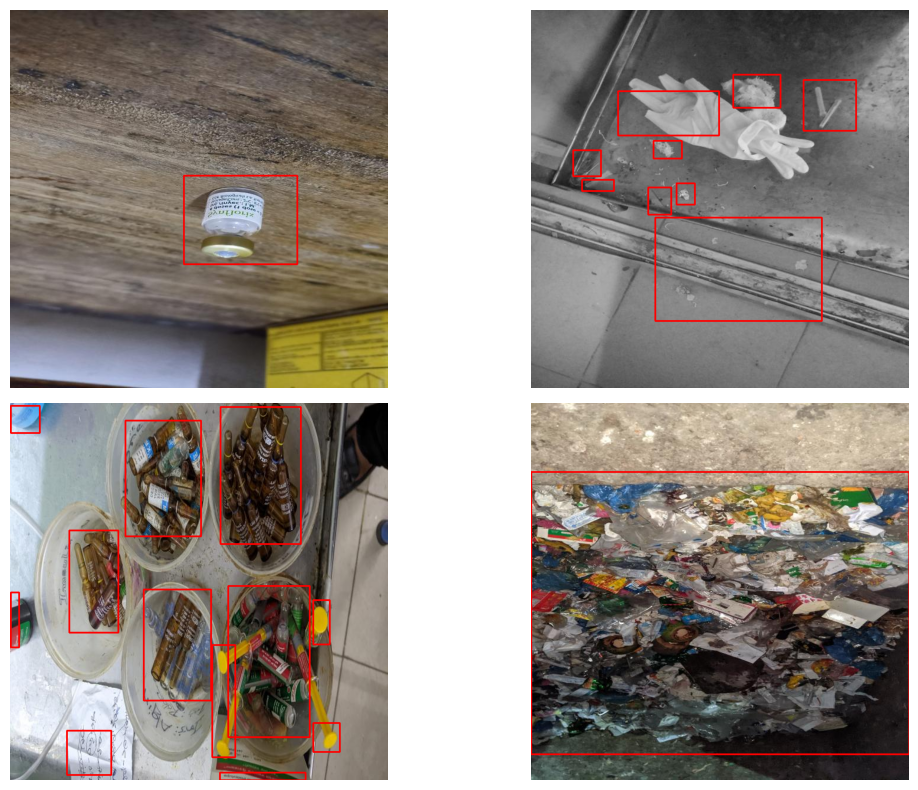

In [22]:
# Visualize sample images with bounding boxes
plot_samples(train_images, os.path.join(dataset_path, "train/labels"))

In [25]:
from ultralytics import YOLO

# Load YOLOv8 model
yolo_model = YOLO("yolov8n.pt")  # Using the nano version for efficiency


100%|██████████| 6.25M/6.25M [00:11<00:00, 557kB/s] 


In [ ]:
# Fine-tuning YOLOv8 with a lower learning rate
yolo_model.train(
    data="dataset/data.yaml",  # Path to your dataset configuration
    epochs=100,  # Train longer for fine-tuning
    batch=8,  # Increase if GPU memory allows
    imgsz=640,  # Resize images to 640x640
    lr0=0.001,  # Lower initial learning rate for fine-tuning
    weight_decay=0.0005,  # Helps generalization
    patience=20,  # Stop if no improvement after 20 epochs
    optimizer="AdamW",  # Better optimizer for fine-tuning
    dropout=0.1,  # Prevents overfitting
    pretrained=True
    workers=2,  # Reduce workers for stability
    cache=False,# Keep pretrained weights
    device="mps" if torch.backends.mps.is_available() else "cpu",  # Use Apple GPU (MPS) if available
)


Ultralytics 8.3.92 🚀 Python-3.9.6 torch-2.6.0 MPS (Apple M1)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=mps, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format

train: Scanning /Users/devayushrout/Desktop/MedWaste Guardian/dataset/train/labels... 982 images, 3 backgrounds, 0 corrupt: 100%|██████████| 982/982 [00:00<00:00, 4042.95it/s]

train: New cache created: /Users/devayushrout/Desktop/MedWaste Guardian/dataset/train/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 35, len(boxes) = 2794. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



val: Scanning /Users/devayushrout/Desktop/MedWaste Guardian/dataset/valid/labels... 100 images, 1 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<00:00, 1079.12it/s]

val: New cache created: /Users/devayushrout/Desktop/MedWaste Guardian/dataset/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 315. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

WARNING ⚠️ NMS time limit 3.600s exceeded


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [02:39<00:00, 39.98s/it]


                   all        100        315     0.0147     0.0476     0.0218     0.0137

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       2/50      4.42G      1.624       3.88      1.633         98        640:  21%|██        | 13/62 [03:26<12:57, 15.86s/it]


KeyboardInterrupt: 

In [ ]:
# Evaluate on validation set
metrics = yolo_model.val()

In [ ]:
# Print evaluation results
print("mAP_50-95:", metrics.box.map50_95)
print("Precision:", metrics.box.precision)
print("Recall:", metrics.box.recall)

In [ ]:
### **4. Inference on Test Images**

def infer_and_plot(image_path, model):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Run inference
    results = model(img_rgb)
    
    # Plot results
    for result in results:
        result.show()

In [ ]:
# Test on a random image
sample_image = random.choice(glob.glob(test_images + '/*.jpg'))
infer_and_plot(sample_image, yolo_model)
